In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
zip_path = "/content/drive/MyDrive/house_prediction.zip"
import zipfile

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/house_data')

In [9]:
import os

print(os.listdir('/content/house_data'))


['House Price Prediction Dataset.csv']


In [10]:
import pandas as pd

df = pd.read_csv("house_data/House Price Prediction Dataset.csv")

df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [11]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [12]:
df.isnull().sum()
num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

In [13]:
target = "Price"   # change if your dataset uses different name

X = df.drop(target, axis=1)
y = df[target]

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

num_features = X.select_dtypes(include=['int64','float64']).columns
cat_features = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor

lr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

gb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor())
])

lr.fit(X_train, y_train)
gb.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Location', 'Condition', 'Garage'], dtype='object'))])),
                ('model', GradientBoostingRegressor())])

In [17]:
lr_pred = lr.predict(X_test)
gb_pred = gb.predict(X_test)

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    print(name)
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("-"*30)

evaluate("Linear Regression", y_test, lr_pred)
evaluate("Gradient Boosting", y_test, gb_pred)

Linear Regression
MAE: 242867.44926338628
RMSE: 279785.21069002635
------------------------------
Gradient Boosting
MAE: 246316.24931500963
RMSE: 284886.3671154482
------------------------------


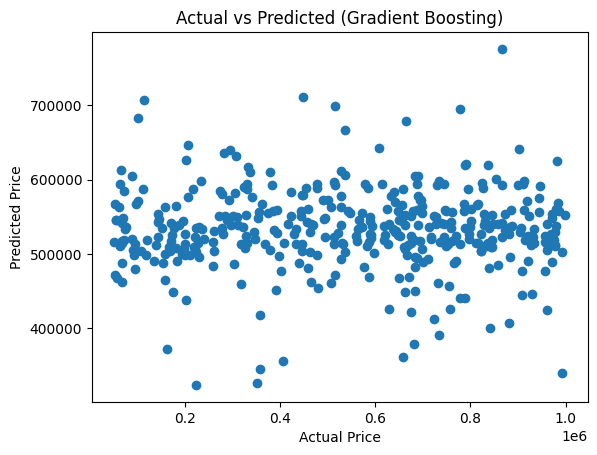

In [19]:
import matplotlib.pyplot as plt

plt.scatter(y_test, gb_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (Gradient Boosting)")
plt.show()

In [20]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Linear Regression": lr_pred,
    "Gradient Boosting": gb_pred
})

results.head()

,Actual,Linear Regression,Gradient Boosting
0,514764,511317.731099,699148.456847
1,694256,557359.556529,517730.482189
2,66375,482838.345234,514569.399560
3,650243,540695.641120,545625.439902
4,223285,549288.502441,535088.206902


In [23]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Linear Regression", "Gradient Boosting"],
    "R2 Score": [lr_r2, gb_r2]
})

results

,Model,R2 Score
0,Linear Regression,-0.006182
1,Gradient Boosting,-0.043206
